# 파이토치

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
import torch

def test_installation():
    print('PyTorch Version:{torch.__version__}')
    if torch.cuda.is_available():
        print('CUDA is available. GPU를 사용합니다.')
        print(f'사용 가능한 GPU 개수: {torch.cuda.device_count()}')
        print(f'현재 GPU 이름: {torch.cuda.get_device_name(0)}')
    else:
        print('CUDA를 사용할 수 없습니다. CPU 모드로 실행합니다.')

test_installation()

PyTorch Version:{torch.__version__}
CUDA is available. GPU를 사용합니다.
사용 가능한 GPU 개수: 1
현재 GPU 이름: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a_cpu = torch.randn(4000, 4000)
b_cpu = torch.randn(4000, 4000)

start_time = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
cpu_time = time.time() - start_time
print(f'CPU 연산 시간: {cpu_time:.4f}초')

if torch.cuda.is_available():
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)

    start_time = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()   # GPU 연산 완료 대기
    gpu_time = time.time() - start_time
    print(f'속도 향상: {cpu_time/gpu_time:.1f}배 빨라짐!')

CPU 연산 시간: 0.1383초
속도 향상: 1.5배 빨라짐!


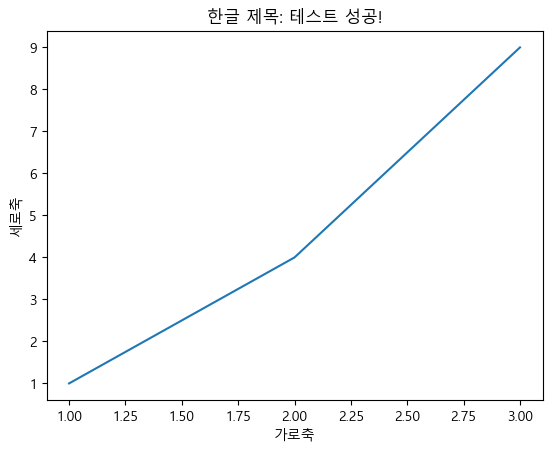

In [5]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

plt.figure()
plt.title("한글 제목: 테스트 성공!")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

# 신경망

In [6]:
# 단층 퍼셉트론

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

print(torch.__version__)

cuda
2.11.0+cu128


In [8]:
torch.manual_seed(42)
np.random.seed(42)

In [9]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])
    b = torch.tensor(-0.7)
    x = torch.tensor([x1, x2], dtype = torch.float32)
    output = torch.dot(w, x) + b
    return 1 if output >= 0 else 0

print(perceptron_and(0, 0))
print(perceptron_and(0, 1))
print(perceptron_and(1, 0))
print(perceptron_and(1, 1))


0
0
0
1


In [10]:
class SimpleNN(nn.Module):
    def __init__(self): # 층 정의
        super(SimpleNN, self).__init__()
        # nn.Linear(입력차원, 출력차원)
        self.fc1 = nn.Linear(2,3) #층 1 입력 2 -> 출력 3 (은닉층)
        self.fc2 = nn.Linear(3,1) #층 2 입력 3 -> 출력 1 (출력층)

    def forward(self, x): # 계산흐름
        x = torch.relu(self.fc1(x)) # 층1 통과 -> relu (음수제거)
        x = torch.sigmoid(self.fc2(x)) # 층2 통과 -> sigmoid (0~1 확률)
        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [11]:
class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):   # 인자 3개
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [12]:
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
datasets = TensorDataset(X_train, y_train)

dataloader = DataLoader(datasets, batch_size = 32, shuffle = True) # train 일떄는 셔플 true test 일때는 false

In [13]:
# loss 계산 / optimizer 설정 (= 모델이 틀린걸 보고 가중치를 조금씩 고치는 과정임/ 경사하강법으로 개선)

criterion = nn.MSELoss() #손실함수 (숫자예측용)
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad() #기울기 초기화 / 그전에 계산된 기울기 값이 남아있을수 있으므로 초기화
        outputs = model(inputs) # 예측
        loss = criterion(outputs, targets) # loss(손실계산) = criterion(예측(outputs), 정답(targets))
        loss.backward() # loss 기준으로 기울기 계산.
        optimizer.step() # 가중치 업데이트
    print(epoch + 1, loss.item())
    


1 0.9306035041809082
2 1.979332447052002
3 0.524667501449585
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [14]:
#모델 저장
torch.save(model.state_dict(), "model.pth")
model = SimpleNN_Full(input_size = 10, hidden_size = 20, output_size = 1)
model.load_state_dict(torch.load("model.pth"))


<All keys matched successfully>

In [15]:
# 학습률을 10분의 1로 줄이는 방법

def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss nan가 포함되어 있음")

        for param_group in optimizer.param_groups:
            param_group["lr"] *= 0.1 # Learning rate를 0.1배로 줄임.
        return True # nan이 포함되있으면 true 반환
    return False # nan이 없으면 false 반환

sample_loss = torch.tensor(float("nan"))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)


Loss nan가 포함되어 있음
True


In [16]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])


In [17]:
## MNIST 데이터셋 불러오기

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = True,
    transform = transform,
    download = True
)

test_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = False,
    transform = transform,
    download = True
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 149kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.56MB/s]


In [18]:
train_loader = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)

test_loader = DataLoader(dataset = test_dataset, batch_size = 1000, shuffle = False)

print(len(train_loader))
print(len(test_loader))

938
10


In [19]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)


    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    

In [23]:
# 손실함수와 옵티마이저

model = MLP().to(device)

criterion = nn.CrossEntropyLoss() # 다중분류용 손실함수

optimizer = optim.Adam(model.parameters(), lr = 0.001) # Adam optimizer

In [24]:
# 모델 학습

for epoch in range(10):
    model.train() # 학습모드
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # GPU로 데이터 이동
        optimizer.zero_grad() # 기울기 초기화
        output = model(data) # 모델에 데이터 넣어서 예측
        loss = criterion(output, target) # 손실함수 계산
        loss.backward() # 기울기 계산
        optimizer.step() # 가중치 업데이트
    print(epoch + 1, loss.item())

1 0.128468856215477
2 0.010349893011152744
3 0.01019427739083767
4 0.059585604816675186
5 0.09507352858781815
6 0.004609810188412666
7 0.013330415822565556
8 0.19454315304756165
9 0.002237693639472127
10 0.055617205798625946


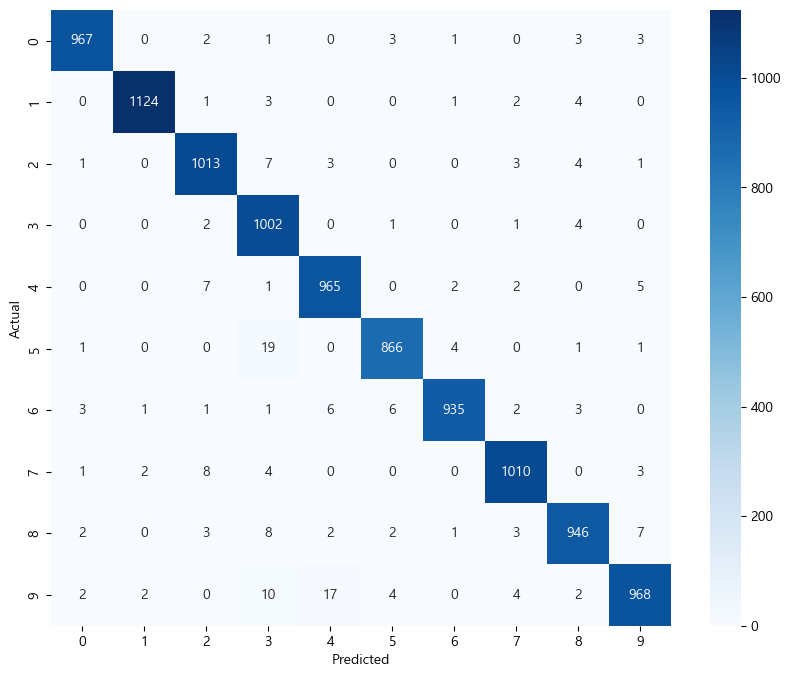

In [ ]:
model.eval() # 평가모드 / 혼동행렬
all_targets = []
all_pred = []

with torch.no_grad(): # 평가모드에서는 기울기 계산 필요없음
    for data, target in test_loader:
        data, target = data.to(device), target.to(device) # GPU로 데이터 이동
        output = model(data) # 모델에 데이터 넣어서 예측
        _, predicted = torch.max(output.data, 1) # 예측값 중 가장 큰 값의 인덱스
        all_targets.extend(target.cpu().numpy()) # 정답값을 리스트에 추가 넘파이로 변환 후 CPU로 이동
        all_pred.extend(predicted.cpu().numpy()) # 예측값을 리스트에 추가 넘파이로 변환 후 CPU로 이동

# 혼동행렬 타켓과 프리드를 넘파이 배열로 변환
targets = np.array(all_targets)
preds = np.array(all_pred)

cm_mnist = confusion_matrix(targets, preds)
plt.figure(figsize = (10, 8))
sns.heatmap(
    cm_mnist, 
    annot = True, 
    fmt = "d", 
    cmap = "Blues", 
    xticklabels = range(10), 
    yticklabels = range(10)
    )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

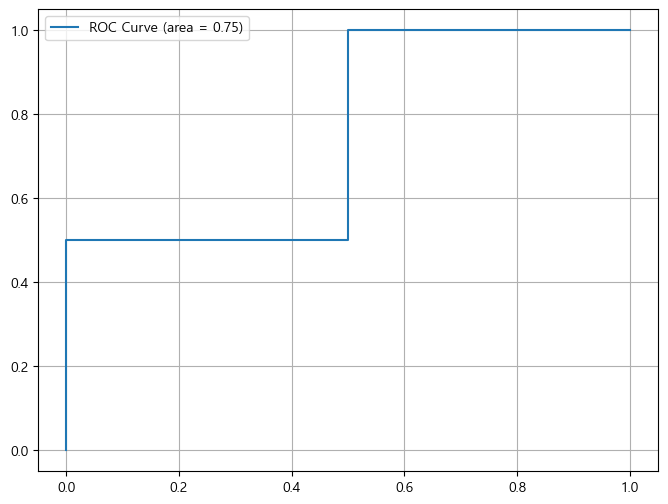

In [26]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label = f"ROC Curve (area = {roc_auc:.2f})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# scheduler = ReduceLROnPlateau(optimizer, mode = "min", patience = 3, factor = 0.1)
# for epoch in range(50):
#     # 추후에는 train_loss를 validation loss로 바꿔야함(하단)
#     ## train_one_epoch(model, train_loader, optimizer, criterion) # train loss 계산
#     ## val_loss = evaluate(model, val_loader) # validation loss 계산(하단에 train_loss 대신)
#     ## scheduler.step(val_loss) # validation loss를 기준으로 학습률 조정
#     train_loss = 0.2 * (50 - epoch) # 예시로 train_loss를 감소시키는 값으로 설정
#     scheduler.step(train_loss) # train_loss를 기준으로 학습률 조정


# 배치정규화

In [27]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

# dropout - 과적합을 줄일수 있음.

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.dropout1 = nn.Dropout(0.5) # 50% 날림.(일부만 가지고 학습한다는의미)
        # self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5) # 50% 날림.(일부만 가지고 학습한다는의미)
        # self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # 2차원으로 변환
        x = F.relu(self.dropout1(self.fc1(x)))
        x = F.relu(self.dropout2(self.fc2(x)))
        x = self.fc3(x)
        return x

# 딥러닝 모델 구축 
## 모델학습과정 이해